## Imports

In [12]:
import os
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score
from keras.models import Model
from keras.layers import Input, Dense
from keras.optimizers import Adam
from keras import regularizers
RANDOM_SEED = 42

## Generate the Data Matrix and the Label vector

In [13]:
D_list = []
y_list = []

for subject_id in range(1, 41):
    folder = f'data/s{subject_id}'
    for img_id in range(1, 11):
        img_path = os.path.join(folder, f'{img_id}.pgm')
        img = Image.open(img_path)
        img_arr = np.asarray(img).flatten()
        D_list.append(img_arr)
        y_list.append(subject_id)

D = np.array(D_list)
y = np.array(y_list)
print("Data Matrix Shape: ", D.shape)
print("Label Vector Shape: ", y.shape)

Data Matrix Shape:  (400, 10304)
Label Vector Shape:  (400,)


## Split the Dataset into Training and Test sets

In [14]:
"""
From the Data Matrix D400x10304 keep the odd rows for training and the even rows for
testing. This will give you 5 instances per person for training and 5 instances per person
for testing
"""
X_train_lst = []
X_test_lst = []
y_train_lst = []
y_test_lst = []

for row in range(D.shape[0]):
    if row % 2 == 1:
        X_train_lst.append(D[row])
        y_train_lst.append(y[row])
    else:
        X_test_lst.append(D[row])
        y_test_lst.append(y[row])

X_train = np.array(X_train_lst)
X_test = np.array(X_test_lst)
y_train = np.array(y_train_lst)
y_test = np.array(y_test_lst)
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(200, 10304)
(200,)
(200, 10304)
(200,)


## PCA Implementation

In [15]:
class PCA:
    def __init__(self, cache_dir=None):
        self.mean = None
        self.eigenvalues = None
        self.eigenvectors = None
        self.explained_variance = None
        self.cumulative_variance = None
        self.cache_dir = cache_dir

        # If a cache path is given, try to load saved eigenvalues/vectors
        if cache_dir:
            try:
                self.eigenvalues = np.load(os.path.join(cache_dir, 'eigenvalues.npy'))
                self.eigenvectors = np.load(os.path.join(cache_dir, 'eigenvectors.npy'))
                self.mean = np.load(os.path.join(cache_dir, 'mean.npy'))
                # Calculate explained variance and cumulative variance
                self.explained_variance = self.eigenvalues / np.sum(self.eigenvalues)
                self.cumulative_variance = np.cumsum(self.explained_variance)
                print("Loaded PCA data from cache.")
            except FileNotFoundError:
                print("PCA cache not found. Will compute and save later.")

    def fit(self, X):
        if self.eigenvalues is not None and self.eigenvectors is not None and self.mean is not None:
            return # already computed

        # Mean-center the data
        self.mean = np.mean(X, axis=0)
        X_centered = X - self.mean

        # Calculate covariance Matrix
        cov_matrix = np.cov(X_centered, rowvar=False)

        # Compute eigenvalues and eigenvectors (sorted ascendingly)
        eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

        # Make them sorted in descending order
        self.eigenvalues = eigenvalues[::-1]
        self.eigenvectors = eigenvectors[:, ::-1]

        # Calculate explained variance and cumulative variance
        self.explained_variance = self.eigenvalues / np.sum(self.eigenvalues)
        self.cumulative_variance = np.cumsum(self.explained_variance)

        # Save to cache if specified
        if self.cache_dir:
            # Ensure the directory exists
            os.makedirs(self.cache_dir, exist_ok=True)
            np.save(os.path.join(self.cache_dir, 'eigenvalues.npy'), self.eigenvalues)
            np.save(os.path.join(self.cache_dir, 'eigenvectors.npy'), self.eigenvectors)
            np.save(os.path.join(self.cache_dir, 'mean.npy'), self.mean)
    
    def transform(self, X, threshold): 
        if self.eigenvectors is None:
            raise Exception("Must call fit() before transform().")
        
        n_components = np.searchsorted(self.cumulative_variance, threshold) + 1
        pcs = self.eigenvectors[:, :n_components]
        X_centered = X - self.mean
        return np.dot(X_centered, pcs), n_components
    
    def inverse_transform(self, X_pca, n_components):
        if self.eigenvectors is None:
            raise Exception("Must call fit() before inverse_transform().")
        pcs = self.eigenvectors[:, :n_components]
        return np.dot(X_pca, pcs.T) + self.mean 


In [16]:
def visualize_faces(X_train, pca, n_faces=5, pca_threshold=0.9):
    # Randomly choose n_faces indices from the training data
    np.random.seed(RANDOM_SEED)
    indices = np.random.choice(X_train.shape[0], size=n_faces, replace=False)
    sampled_faces = X_train[indices]

    sampled_faces_pca, n_components = pca.transform(sampled_faces, pca_threshold)

    # Approximately reconstruct the faces back to the original space
    reconstructed_faces = pca.inverse_transform(sampled_faces_pca, n_components)

    fig, axes = plt.subplots(2, n_faces, figsize=(3 * n_faces, 6))

    fig.suptitle(f"Original (Top) vs Reconstructed (Bottom)\nPCA Threshold = {pca_threshold * 100:.1f}%", weight='bold', fontsize=16)

    for i in range(n_faces):
        # Top row: original faces
        axes[0, i].imshow(sampled_faces[i].reshape(112, 92), cmap='gray')
        axes[0, i].axis('off')
        axes[0, i].set_title(f"Original #{indices[i]}", fontsize=10)

        # Bottom row: reconstructed faces
        axes[1, i].imshow(reconstructed_faces[i].reshape(112, 92), cmap='gray')
        axes[1, i].axis('off')
        axes[1, i].set_title(f"Reconstructed #{indices[i]}", fontsize=10)

    fig.tight_layout()
    plt.subplots_adjust(top=0.85)
    plt.show()

Loaded PCA data from cache.
at Alpha = 0.8, Components Retained (Dimensionality) = 37


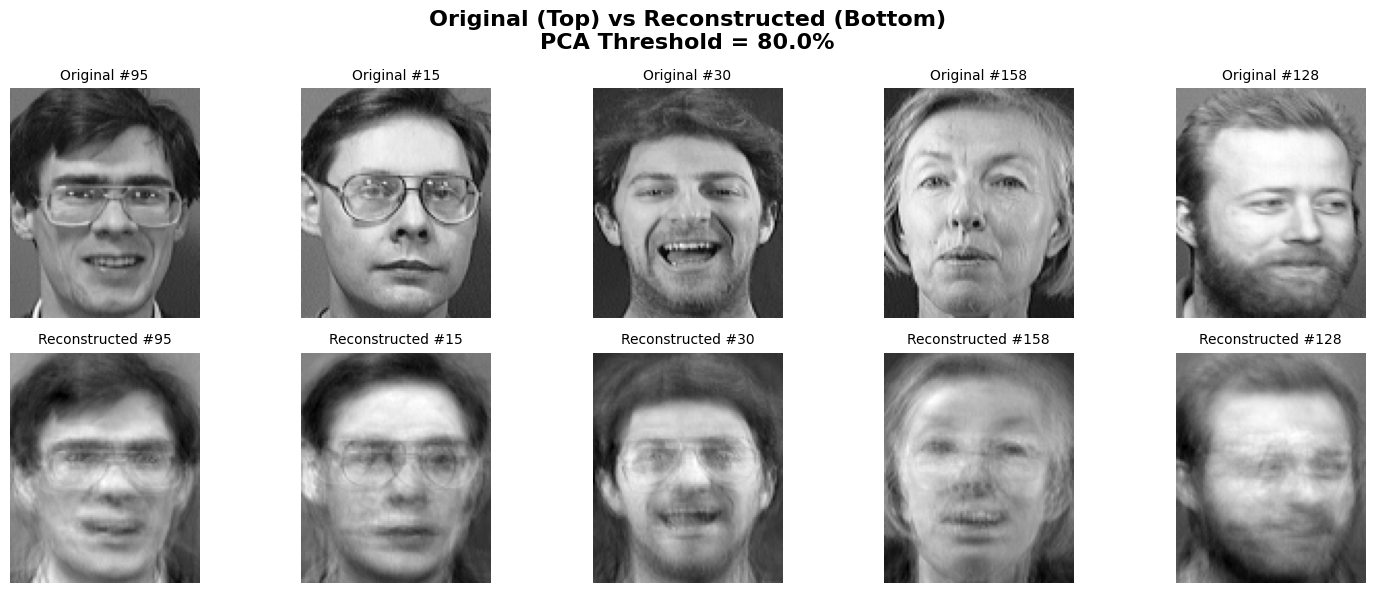

at Alpha = 0.85, Components Retained (Dimensionality) = 53


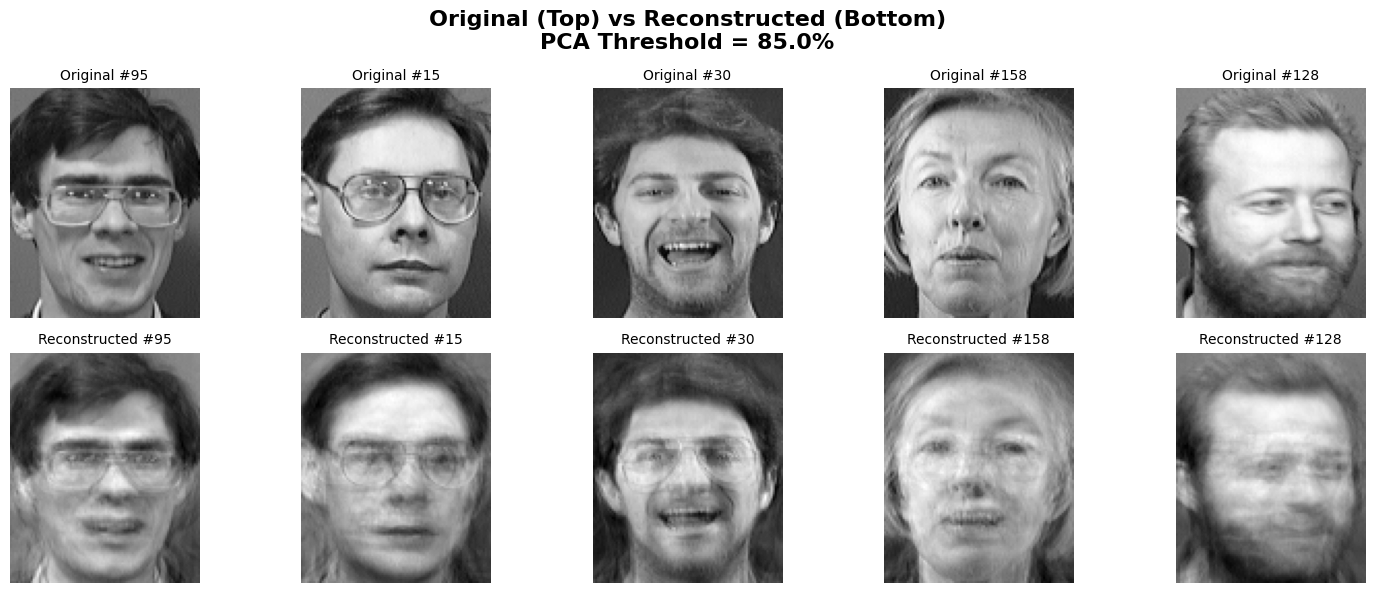

at Alpha = 0.9, Components Retained (Dimensionality) = 77


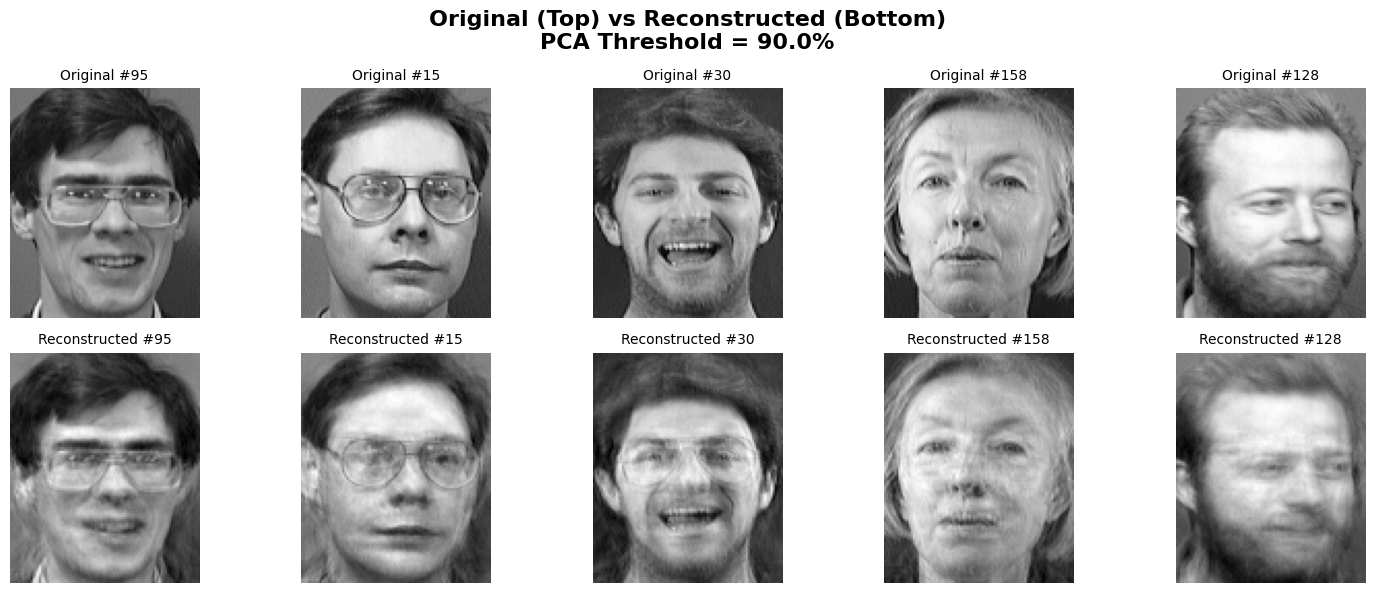

at Alpha = 0.95, Components Retained (Dimensionality) = 116


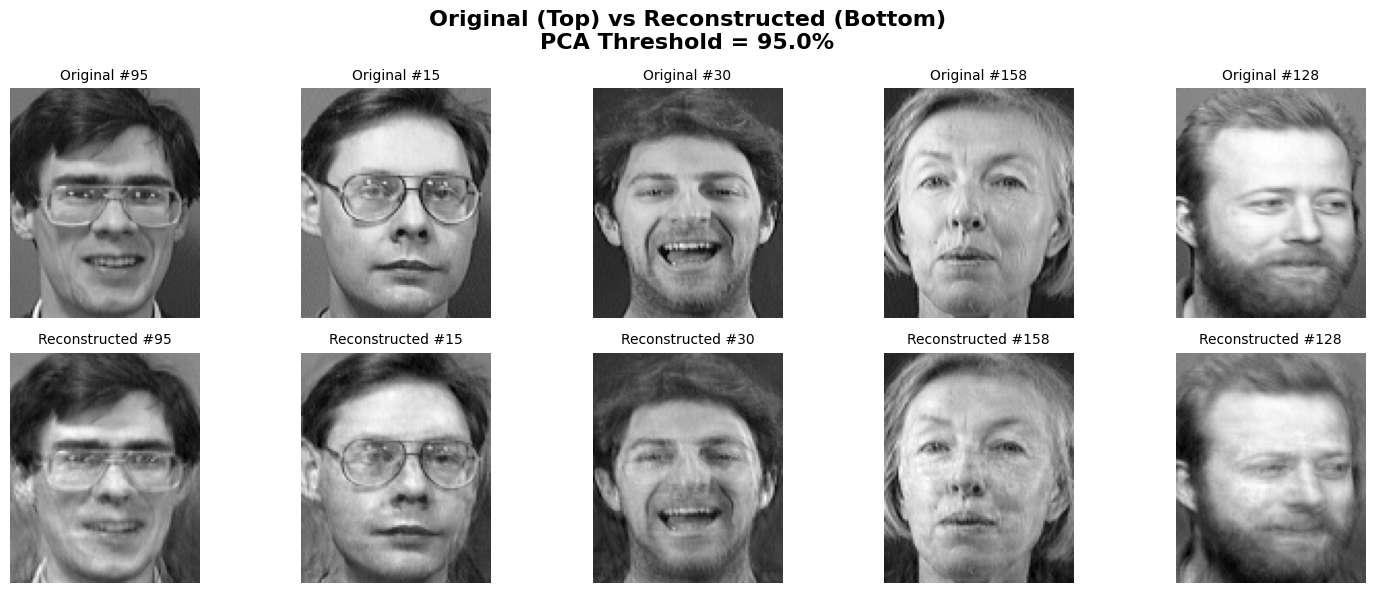

In [17]:
# Project the dataset into the reduced PCA subspace and report dimensionality 
# and visualize reconstructed samples for different thresholds
pca = PCA(cache_dir="pca_results")
pca.fit(X_train)

pca_projections = {} # will store X_train_pca, X_test_pca, n_components for each alpha

for alpha in [0.8, 0.85, 0.9, 0.95]:
    X_train_pca, n_components = pca.transform(X_train, alpha)
    X_test_pca, _ = pca.transform(X_test, alpha)
    pca_projections[alpha] = {
        "train": X_train_pca,
        "test": X_test_pca,
        "n_components": n_components
    }
    print(f"at Alpha = {alpha}, Components Retained (Dimensionality) = {n_components}")
    visualize_faces(X_train, pca, n_faces=5, pca_threshold=alpha)

# GMM Implementation
$\mathcal{N}(x;\mu,\Sigma)$ = $\frac{1}{(2\pi)^{d/2}|\Sigma|^{1/2}}e^{-\frac{1}{2}(x-\mu)^T\Sigma^{-1}(x-\mu)}$

In [38]:
class GMM:
    def __init__(self, n_components, max_iter=100, tol=1e-6, random_state=RANDOM_SEED, reg_covar=1e-6, init_params='kmeans'):
        self.n_components = n_components
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state
        self.reg_covar = reg_covar  
        self.weights = None
        self.means = None
        self.covariances = None
        self.init_params = init_params  # 'kmeans' or 'random'
    
    def initialize_parameters(self, X):
        n_samples, n_features = X.shape
        self.weights = np.ones(self.n_components) / self.n_components
        random_state = np.random.RandomState(self.random_state)
        if self.init_params == 'kmeans':
            from sklearn.cluster import KMeans
            kmeans = KMeans(n_clusters=self.n_components, random_state=random_state).fit(X)
            self.means = kmeans.cluster_centers_
        else:
            self.means = X[random_state.choice(n_samples, self.n_components, replace=False)]
        # Initialize covariance matrices with a small regularization term
        self.covariances = np.array([np.cov(X, rowvar=False) + self.reg_covar * np.eye(n_features) for _ in range(self.n_components)])
        

    def multivariate_gaussian(self, X, mean, covariance):
        n_features = X.shape[1]
        diff = X - mean
        cov_inv = np.linalg.pinv(covariance)  
        term = np.sum(diff @ cov_inv * diff, axis=1)
        sign, logdet = np.linalg.slogdet(covariance)
        if sign != 1:
            logdet = np.inf  
        log_prob = -0.5 * (n_features * np.log(2 * np.pi) + logdet + term)
        return np.exp(log_prob)
    
    def e_step(self, X):
        responsibilities = np.zeros((X.shape[0], self.n_components))
        for k in range(self.n_components):
            responsibilities[:, k] = self.weights[k] * self.multivariate_gaussian(X, self.means[k], self.covariances[k])
        responsibilities_sum = responsibilities.sum(axis=1, keepdims=True)
        responsibilities_sum[responsibilities_sum == 0] = 1e-10  # Avoid division by zero
        responsibilities /= responsibilities_sum
        return responsibilities, responsibilities_sum
    
    def m_step(self, X, responsibilities):
        n_samples, n_features = X.shape
        NK = responsibilities.sum(axis=0)
        # Avoid division by zero
        NK[NK == 0] = 1e-10  # Small value to prevent division by zero
        self.weights = NK / n_samples
        self.means = (responsibilities.T @ X) / NK[:, np.newaxis]
        self.covariances = np.zeros((self.n_components, n_features, n_features))
        
        for k in range(self.n_components):
            diff = X - self.means[k]
            self.covariances[k] = (responsibilities[:, k][:, np.newaxis] * diff).T @ diff / NK[k]
            # Regularization to ensure positive definiteness
            self.covariances[k] += self.reg_covar * np.eye(n_features)

    def fit(self, X):
        self.initialize_parameters(X)
        last_log_likelihood = None

        for i in range(self.max_iter):
            responsibilities, responsibilities_sum = self.e_step(X)
            self.m_step(X, responsibilities)

            log_likelihood = np.sum(np.log(responsibilities_sum))
            if last_log_likelihood is not None and abs(log_likelihood - last_log_likelihood) < self.tol:
                print(f"Converged after {i + 1} iterations.")
                break
            last_log_likelihood = log_likelihood

    def predict(self, X):
        n_samples = X.shape[0]
        probs = np.zeros((n_samples, self.n_components))
        for k in range(self.n_components):
            probs[:, k] = self.weights[k] * self.multivariate_gaussian(X, self.means[k], self.covariances[k])
        return np.argmax(probs, axis=1)


In [39]:
def plot_log_likelihood(gmm):
    plt.figure(figsize=(8,5))
    plt.plot(gmm.log_likelihoods, marker='o')
    plt.title('Log-Likelihood over EM Iterations', fontsize=14)
    plt.xlabel('Iteration', fontsize=12)
    plt.ylabel('Log-Likelihood', fontsize=12)
    plt.grid()
    plt.show()

In [40]:
def compute_clustering_accuracy(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    row_ind, col_ind = linear_sum_assignment(-cm)
    best_mapping = dict(zip(col_ind, row_ind))
    y_pred_aligned = np.array([best_mapping.get(pred, pred) for pred in y_pred])

    acc = accuracy_score(y_true, y_pred_aligned)
    f1 = f1_score(y_true, y_pred_aligned, average='macro')
    return acc, f1, cm, y_pred_aligned

In [41]:
gmm_results = {}

for init_params in ['random', 'kmeans']:
    for alpha, projections in pca_projections.items():
        X_train_pca = projections["train"]
        y_train_true = y_train

        for K in [20, 40, 60]:
            gmm = GMM(n_components=K, max_iter=100, tol=1e-6, random_state=RANDOM_SEED, init_params=init_params)
            gmm.fit(X_train_pca)
            y_train_pred = gmm.predict(X_train_pca)
            accuracy, f1, cm, y_train_pred_aligned = compute_clustering_accuracy(y_train_true, y_train_pred)
            gmm_results[(init_params, alpha, K)] = {
                "gmm": gmm,
                "accuracy": accuracy,
                "f1_score": f1,
                "cm": cm
            }

            print(f"GMM with init_params={init_params}, alpha={alpha}, K={K}: Accuracy={accuracy:.4f}, F1 Score={f1:.4f}")

gmm_df = pd.DataFrame.from_dict(
    {k: {"init_params": k[0], "alpha": k[1], "K": k[2], "accuracy": v["accuracy"], "f1_score": v["f1_score"]} for k, v in gmm_results.items()},
    orient='index'
)
# gmm_df = gmm_df.sort_values(by='accuracy', ascending=False)
print("\nGMM Results DataFrame:")
print(gmm_df)

# Find and report the best GMM model
print("\nBest GMM Model:")
best_gmm_key = gmm_df.loc[gmm_df['accuracy'].idxmax()]
best_gmm = gmm_results[(best_gmm_key['init_params'], best_gmm_key['alpha'], best_gmm_key['K'])]['gmm']
print(f"Init Params: {best_gmm_key['init_params']}, Alpha: {best_gmm_key['alpha']}, K: {best_gmm_key['K']} With Accuracy: {best_gmm_key['accuracy']:.4f}, F1 Score: {best_gmm_key['f1_score']:.4f}")

Converged after 6 iterations.
GMM with init_params=random, alpha=0.8, K=20: Accuracy=0.3750, F1 Score=0.2714
Converged after 6 iterations.
GMM with init_params=random, alpha=0.8, K=40: Accuracy=0.5450, F1 Score=0.5144
Converged after 6 iterations.
GMM with init_params=random, alpha=0.8, K=60: Accuracy=0.5800, F1 Score=0.4231
Converged after 5 iterations.
GMM with init_params=random, alpha=0.85, K=20: Accuracy=0.3200, F1 Score=0.2369
Converged after 5 iterations.
GMM with init_params=random, alpha=0.85, K=40: Accuracy=0.4750, F1 Score=0.4491
Converged after 5 iterations.
GMM with init_params=random, alpha=0.85, K=60: Accuracy=0.5500, F1 Score=0.3971
Converged after 5 iterations.
GMM with init_params=random, alpha=0.9, K=20: Accuracy=0.2800, F1 Score=0.2257
Converged after 6 iterations.
GMM with init_params=random, alpha=0.9, K=40: Accuracy=0.3900, F1 Score=0.3701
Converged after 5 iterations.
GMM with init_params=random, alpha=0.9, K=60: Accuracy=0.4800, F1 Score=0.3506
Converged after 

/home/go3rany/.local/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


Converged after 6 iterations.
GMM with init_params=kmeans, alpha=0.8, K=20: Accuracy=0.4550, F1 Score=0.3300


/home/go3rany/.local/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


Converged after 6 iterations.
GMM with init_params=kmeans, alpha=0.8, K=40: Accuracy=0.7400, F1 Score=0.7088


...

Converged after 2 iterations.
GMM with init_params=kmeans, alpha=0.95, K=20: Accuracy=0.0250, F1 Score=0.0012


/home/go3rany/.local/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


Converged after 3 iterations.
GMM with init_params=kmeans, alpha=0.95, K=40: Accuracy=0.0350, F1 Score=0.0179


/home/go3rany/.local/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


Converged after 3 iterations.
GMM with init_params=kmeans, alpha=0.95, K=60: Accuracy=0.0500, F1 Score=0.0377

GMM Results DataFrame:
               init_params  alpha   K  accuracy  f1_score
random 0.80 20      random   0.80  20     0.375  0.271413
            40      random   0.80  40     0.545  0.514385
            60      random   0.80  60     0.580  0.423069
       0.85 20      random   0.85  20     0.320  0.236913
            40      random   0.85  40     0.475  0.449144
            60      random   0.85  60     0.550  0.397145
       0.90 20      random   0.90  20     0.280  0.225736
            40      random   0.90  40     0.390  0.370128
            60      random   0.90  60     0.480  0.350618
       0.95 20      random   0.95  20     0.105  0.134677
            40      random   0.95  40     0.155  0.210537
            60      random   0.95  60     0.200  0.194007
kmeans 0.80 20      kmeans   0.80  20     0.455  0.330014
            40      kmeans   0.80  40     0.740  0.708


Tabulated Results for init_params=random:
alpha   0.80   0.85  0.90   0.95
K                               
20     0.375  0.320  0.28  0.105
40     0.545  0.475  0.39  0.155
60     0.580  0.550  0.48  0.200

Tabulated Results for init_params=kmeans:
alpha   0.80  0.85   0.90   0.95
K                               
20     0.455  0.45  0.470  0.025
40     0.740  0.71  0.675  0.035
60     0.715  0.73  0.720  0.050


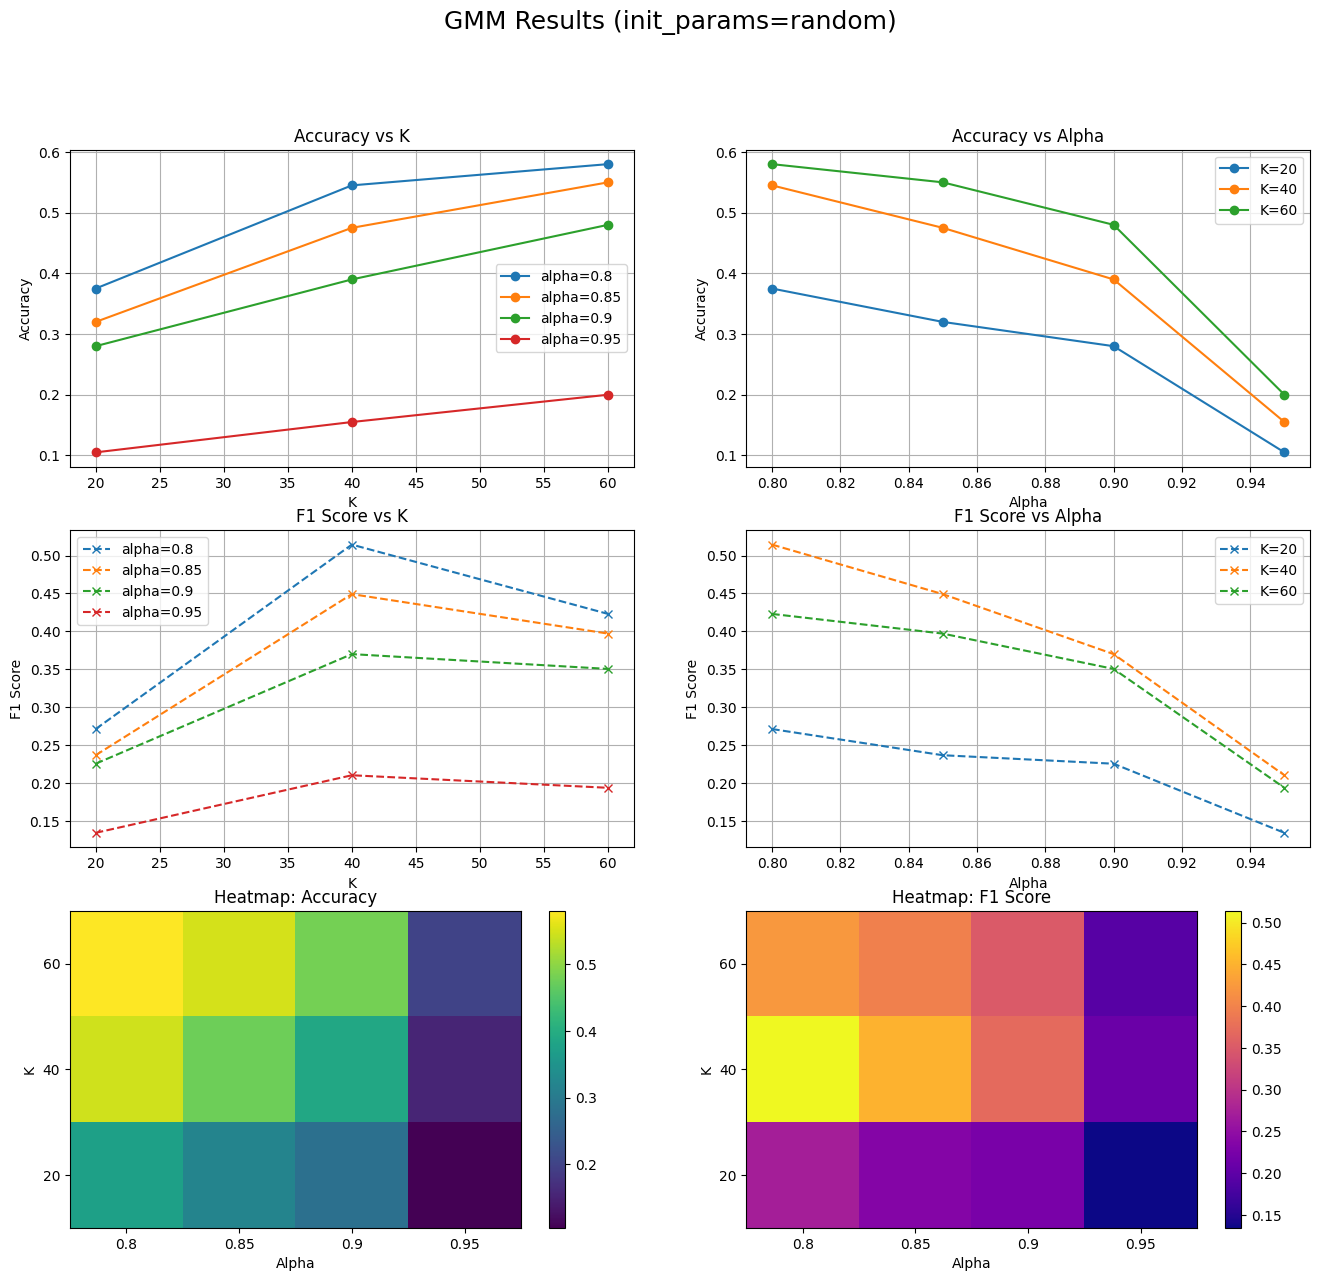

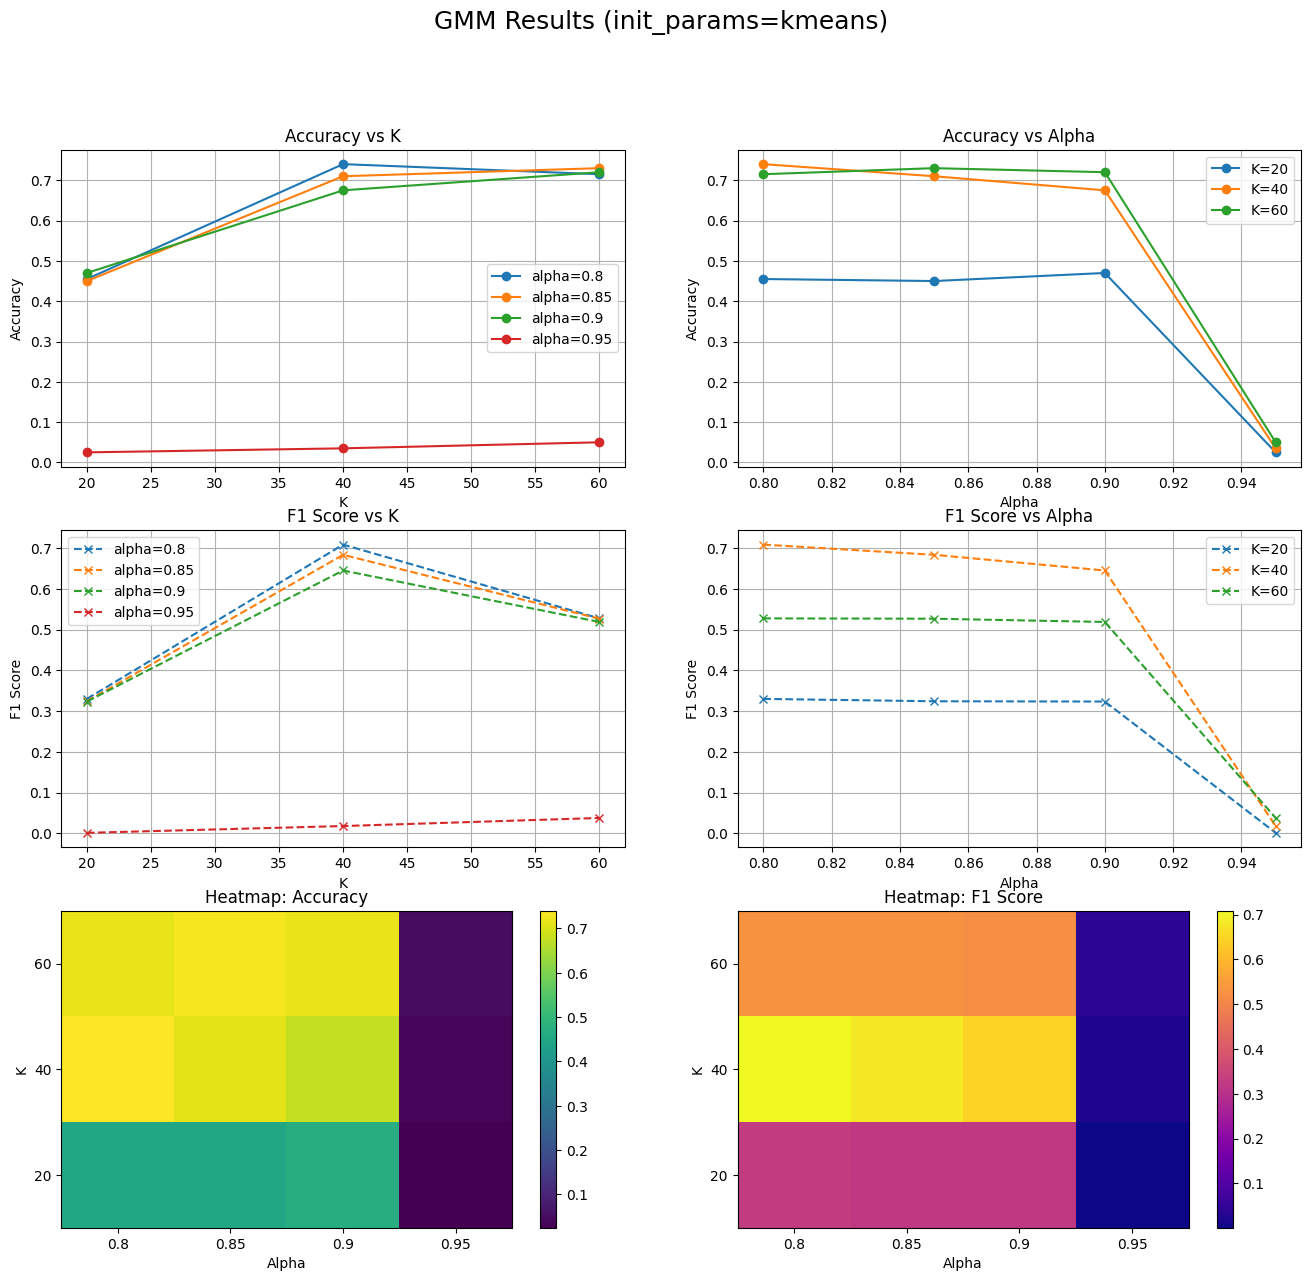

In [23]:
for init_param in gmm_df['init_params'].unique():
    df = gmm_df[gmm_df['init_params'] == init_param]

    fig, axs = plt.subplots(3, 2, figsize=(16, 14))
    fig.suptitle(f'GMM Results (init_params={init_param})', fontsize=18)

    # Plot 1: Accuracy vs K for each alpha
    ax = axs[0, 0]
    for alpha in sorted(df['alpha'].unique()):
        df_alpha = df[df['alpha'] == alpha]
        ax.plot(df_alpha['K'], df_alpha['accuracy'], marker='o', label=f'alpha={alpha}')
    ax.set_title('Accuracy vs K')
    ax.set_xlabel('K')
    ax.set_ylabel('Accuracy')
    ax.grid(True)
    ax.legend()

    # Plot 2: Accuracy vs Alpha for each K
    ax = axs[0, 1]
    for K in sorted(df['K'].unique()):
        df_K = df[df['K'] == K]
        ax.plot(df_K['alpha'], df_K['accuracy'], marker='o', label=f'K={K}')
    ax.set_title('Accuracy vs Alpha')
    ax.set_xlabel('Alpha')
    ax.set_ylabel('Accuracy')
    ax.grid(True)
    ax.legend()

    # Plot 3: F1 Score vs K for each alpha
    ax = axs[1, 0]
    for alpha in sorted(df['alpha'].unique()):
        df_alpha = df[df['alpha'] == alpha]
        ax.plot(df_alpha['K'], df_alpha['f1_score'], marker='x', linestyle='--', label=f'alpha={alpha}')
    ax.set_title('F1 Score vs K')
    ax.set_xlabel('K')
    ax.set_ylabel('F1 Score')
    ax.grid(True)
    ax.legend()

    # Plot 4: F1 Score vs Alpha for each K
    ax = axs[1, 1]
    for K in sorted(df['K'].unique()):
        df_K = df[df['K'] == K]
        ax.plot(df_K['alpha'], df_K['f1_score'], marker='x', linestyle='--', label=f'K={K}')
    ax.set_title('F1 Score vs Alpha')
    ax.set_xlabel('Alpha')
    ax.set_ylabel('F1 Score')
    ax.grid(True)
    ax.legend()

    # Plot 5: Heatmap of Accuracy
    ax = axs[2, 0]
    pivot_table = df.pivot(index='K', columns='alpha', values='accuracy')
    cax = ax.imshow(pivot_table, cmap='viridis', aspect='auto', origin='lower')
    ax.set_title('Heatmap: Accuracy')
    ax.set_xlabel('Alpha')
    ax.set_ylabel('K')
    ax.set_xticks(range(len(pivot_table.columns)))
    ax.set_xticklabels(pivot_table.columns)
    ax.set_yticks(range(len(pivot_table.index)))
    ax.set_yticklabels(pivot_table.index)
    fig.colorbar(cax, ax=ax)

    # Plot 6: Heatmap of F1 Score
    ax = axs[2, 1]
    pivot_table_f1 = df.pivot(index='K', columns='alpha', values='f1_score')
    cax_f1 = ax.imshow(pivot_table_f1, cmap='plasma', aspect='auto', origin='lower')
    ax.set_title('Heatmap: F1 Score')
    ax.set_xlabel('Alpha')
    ax.set_ylabel('K')
    ax.set_xticks(range(len(pivot_table_f1.columns)))
    ax.set_xticklabels(pivot_table_f1.columns)
    ax.set_yticks(range(len(pivot_table_f1.index)))
    ax.set_yticklabels(pivot_table_f1.index)
    fig.colorbar(cax_f1, ax=ax)
    
    # Tabulated print
    print(f"\nTabulated Results for init_params={init_param}:")
    print(df.pivot_table(index='K', columns='alpha', values='accuracy', aggfunc='mean'))


3. **Relation between alpha and accuracy:**
For both random and kmeans initializations, as alpha increases, the accuracy tends to improve at lower values of K (e.g., K=20). However, for higher alpha values (like 0.95), the accuracy significantly drops, especially for larger K values (e.g., K=60).

4. **Relation between K and accuracy:**
Accuracy increases as K grows from 20 to 60 for both initialization methods, but the improvements are more pronounced when init_params='kmeans'. After reaching a certain K value (e.g., 40-60), the accuracy stabilizes or even drops with very high alpha values

# Autoencoder Implementation

In [33]:
class Autoencoder:
    def __init__(self, input_dim, 
                 encoding_dim=100, 
                 hidden_layers=[512, 256],
                 learning_rate=1e-3):
        """
        Autoencoder constructor.

        Args:
            input_dim (int): Size of input feature vector (10304 for ORL).
            encoding_dim (int): Size of bottleneck layer.
            hidden_layers (list of int): Sizes of encoder hidden layers (decoder will mirror them).
            learning_rate (float): Learning rate for optimizer.
        """
        self.input_dim = input_dim
        self.encoding_dim = encoding_dim
        self.hidden_layers = hidden_layers
        self.learning_rate = learning_rate
        
        self.autoencoder = None
        self.encoder = None
        self.history = None
        
        self.build_model()

    def build_model(self):
        input_img = Input(shape=(self.input_dim,))
        x = input_img

        # Encoder hidden layers
        for units in self.hidden_layers:
            x = Dense(units, activation='relu')(x)
        
        # Bottleneck
        encoded = Dense(self.encoding_dim, activation='relu')(x)

        # Decoder hidden layers (mirror of encoder)
        x = encoded
        for units in reversed(self.hidden_layers):
            x = Dense(units, activation='relu')(x)
        
        # Output layer
        decoded = Dense(self.input_dim, activation='sigmoid')(x)
        
        # Build models
        self.autoencoder = Model(input_img, decoded)
        self.encoder = Model(input_img, encoded)
        
        self.autoencoder.compile(optimizer=Adam(learning_rate=self.learning_rate), loss='mse')

    def fit(self, X_train, X_val=None, epochs=50, batch_size=32, shuffle=True):
        if X_val is not None:
            validation_data = (X_val, X_val)
        else:
            validation_data = None
        
        self.history = self.autoencoder.fit(
            X_train, X_train,
            epochs=epochs,
            batch_size=batch_size,
            shuffle=shuffle,
            validation_data=validation_data,
            verbose=1
        )

    def encode(self, X):
        return self.encoder.predict(X)
    
    def decode(self, encoded_X):
        return self.autoencoder.predict(encoded_X)

    def reconstruct(self, X):
        return self.autoencoder.predict(X)
    
    def plot_reconstructions(self, X, n_faces=5, img_shape=(112, 92)):
        np.random.seed(RANDOM_SEED)
        indices = np.random.choice(X.shape[0], size=n_faces, replace=False)
        X_encoded = self.encode(X)
        X_decoded = self.decode(X)

        fig, axes = plt.subplots(2, n_faces, figsize=(3 * n_faces, 6))
        fig.suptitle("Original (Top) vs Autoencoder Reconstructed (Bottom)", fontsize=16, weight='bold')

        for i, idx in enumerate(indices):
            # Original
            axes[0, i].imshow(X[idx].reshape(img_shape), cmap='gray')
            axes[0, i].axis('off')
            
            # Reconstructed
            axes[1, i].imshow(X_decoded[idx].reshape(img_shape), cmap='gray')
            axes[1, i].axis('off')

        plt.tight_layout()
        plt.subplots_adjust(top=0.85)
        plt.show()


In [34]:
# Normalize
X_train_norm = X_train / 255.0
X_test_norm = X_test / 255.0

# Initialize Autoencoder
autoenc = Autoencoder(
    input_dim=10304,
    encoding_dim=100,
    hidden_layers=[512, 256],
    learning_rate=1e-3
)

# Train
autoenc.fit(X_train_norm, X_val=X_test_norm, epochs=50)

Epoch 1/50
7/7 [==============================] - 3s 269ms/step - loss: 0.0357 - val_loss: 0.0277
Epoch 2/50
7/7 [==============================] - 1s 204ms/step - loss: 0.0273 - val_loss: 0.0248
Epoch 3/50
7/7 [==============================] - 2s 219ms/step - loss: 0.0245 - val_loss: 0.0242
Epoch 4/50
7/7 [==============================] - 2s 228ms/step - loss: 0.0239 - val_loss: 0.0237
Epoch 5/50
7/7 [==============================] - 2s 244ms/step - loss: 0.0239 - val_loss: 0.0244
Epoch 6/50
7/7 [==============================] - 2s 218ms/step - loss: 0.0233 - val_loss: 0.0226
Epoch 7/50
7/7 [==============================] - 1s 217ms/step - loss: 0.0219 - val_loss: 0.0209
Epoch 8/50
7/7 [==============================] - 1s 214ms/step - loss: 0.0201 - val_loss: 0.0199
Epoch 9/50
7/7 [==============================] - 1s 205ms/step - loss: 0.0197 - val_loss: 0.0192
Epoch 10/50
7/7 [==============================] - 2s 224ms/step - loss: 0.0189 - val_loss: 0.0191
Epoch 11/50
7/7 [==

In [35]:
# Encode training and test data
encoded_train = autoenc.encode(X_train_norm)
encoded_test = autoenc.encode(X_test_norm)

7/7 [==============================] - 0s 11ms/step


# Visualization of reconstructed faces

7/7 [==============================] - 0s 12ms/step


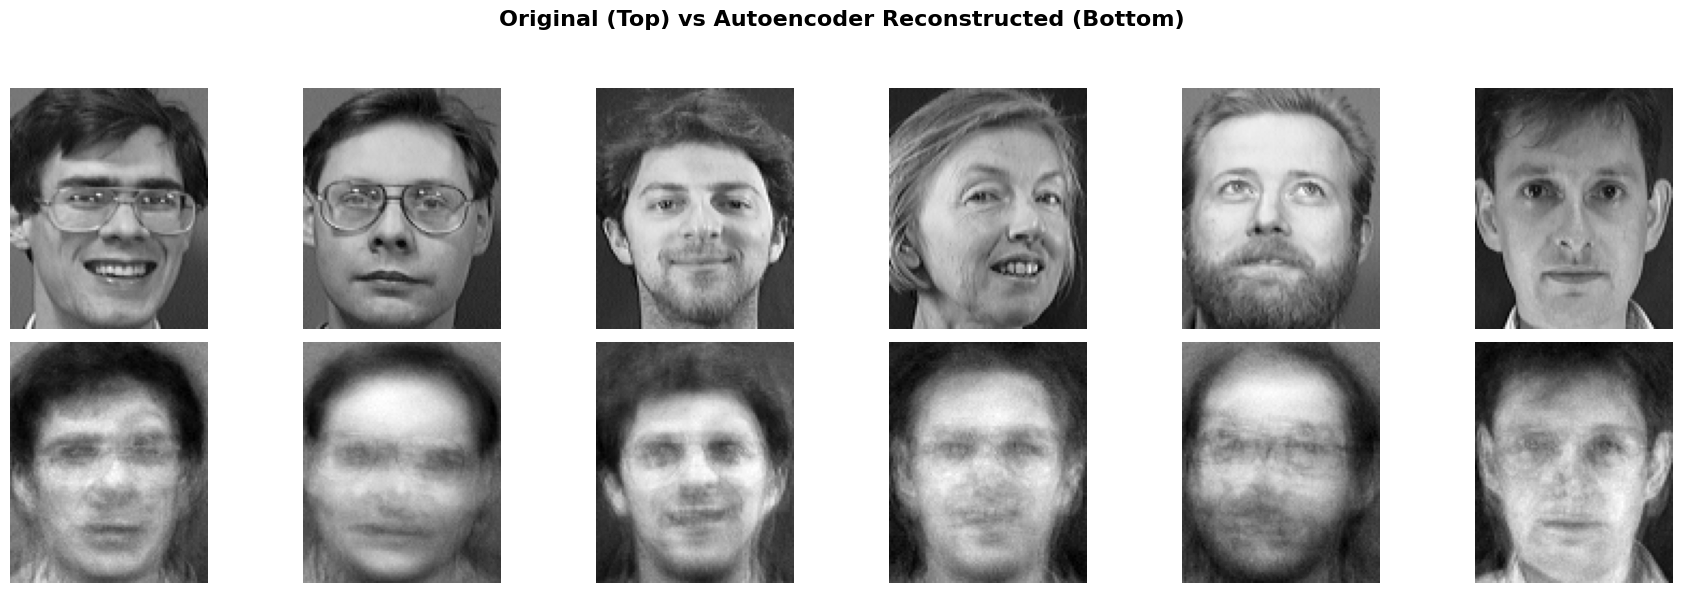

In [36]:
autoenc.plot_reconstructions(X_test_norm, n_faces=6)

# GMM Clustering

Converged after 6 iterations.
GMM with init_params=random, K=20: Accuracy=0.3000, F1 Score=0.2076
Converged after 6 iterations.
GMM with init_params=random, K=40: Accuracy=0.4200, F1 Score=0.3827
Converged after 7 iterations.
GMM with init_params=random, K=60: Accuracy=0.4800, F1 Score=0.3499


/home/go3rany/.local/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


Converged after 5 iterations.
GMM with init_params=kmeans, K=20: Accuracy=0.4650, F1 Score=0.3221


/home/go3rany/.local/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


Converged after 5 iterations.
GMM with init_params=kmeans, K=40: Accuracy=0.6400, F1 Score=0.6083


/home/go3rany/.local/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


Converged after 5 iterations.
GMM with init_params=kmeans, K=60: Accuracy=0.6250, F1 Score=0.4612

GMM Autoencoder Results DataFrame:
          init_params   K  accuracy  f1_score
random 20      random  20     0.300  0.207550
       40      random  40     0.420  0.382695
       60      random  60     0.480  0.349919
kmeans 20      kmeans  20     0.465  0.322085
       40      kmeans  40     0.640  0.608325
       60      kmeans  60     0.625  0.461194

Best GMM Autoencoder Model:
Init Params: kmeans, K: 40 With Accuracy: 0.6400, F1 Score: 0.6083


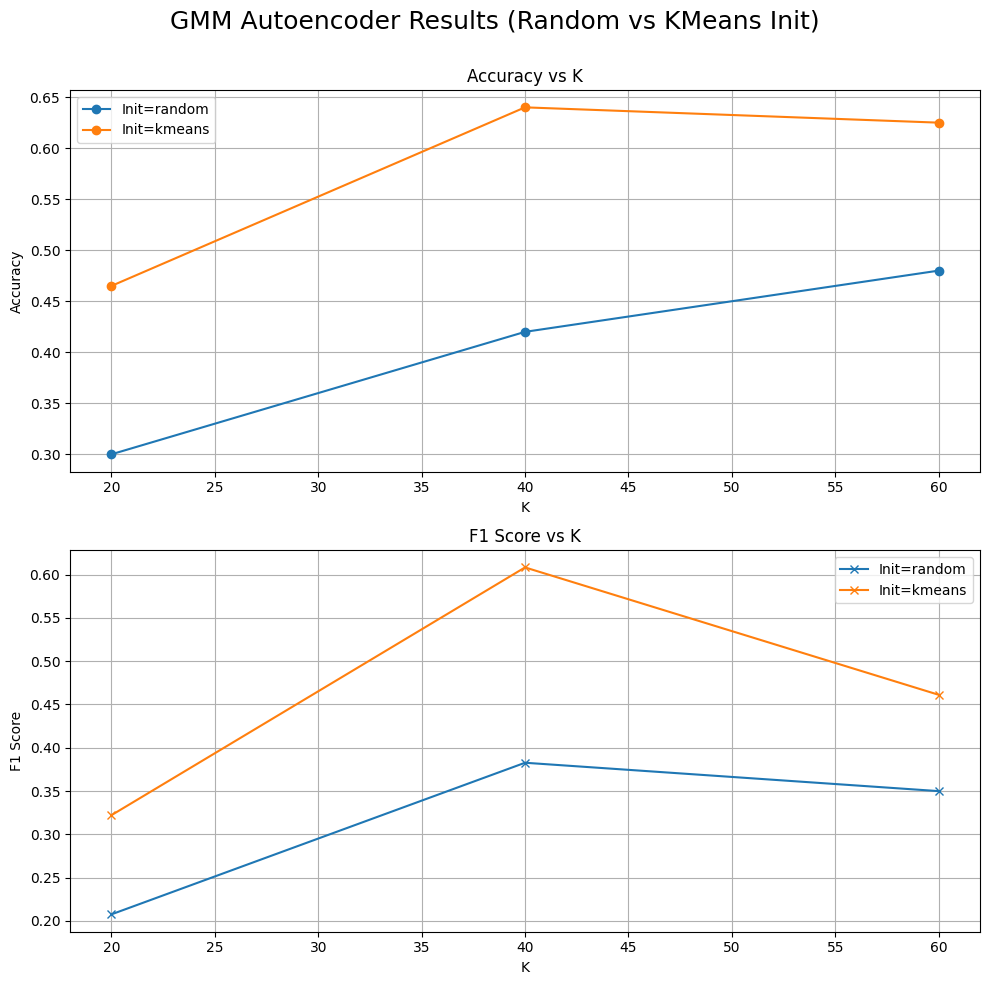


Tabulated Results for GMM Autoencoder:
init_params  kmeans  random
K                          
20            0.465    0.30
40            0.640    0.42
60            0.625    0.48


In [37]:
gmm_autoenc_results = {}
for init_params in ['random', 'kmeans']:
    for K in [20, 40, 60]:
        gmm = GMM(n_components=K, max_iter=100, tol=1e-6, random_state=RANDOM_SEED, init_params=init_params)
        gmm.fit(encoded_train)
        y_train_pred = gmm.predict(encoded_train)
        accuracy, f1, cm, y_train_pred_aligned = compute_clustering_accuracy(y_train, y_train_pred)
        gmm_autoenc_results[(init_params, K)] = {
            "gmm": gmm,
            "accuracy": accuracy,
            "f1_score": f1,
            "cm": cm
        }

        print(f"GMM with init_params={init_params}, K={K}: Accuracy={accuracy:.4f}, F1 Score={f1:.4f}")
gmm_autoenc_df = pd.DataFrame.from_dict(
    {k: {"init_params": k[0], "K": k[1], "accuracy": v["accuracy"], "f1_score": v["f1_score"]} for k, v in gmm_autoenc_results.items()},
    orient='index'
)
print("\nGMM Autoencoder Results DataFrame:")
print(gmm_autoenc_df)
print("\nBest GMM Autoencoder Model:")
best_gmm_autoenc_key = gmm_autoenc_df.loc[gmm_autoenc_df['accuracy'].idxmax()]
best_gmm_autoenc = gmm_autoenc_results[(best_gmm_autoenc_key['init_params'], best_gmm_autoenc_key['K'])]['gmm']
print(f"Init Params: {best_gmm_autoenc_key['init_params']}, K: {best_gmm_autoenc_key['K']} With Accuracy: {best_gmm_autoenc_key['accuracy']:.4f}, F1 Score: {best_gmm_autoenc_key['f1_score']:.4f}")

fig, axs = plt.subplots(2, 1, figsize=(10, 10))
fig.suptitle('GMM Autoencoder Results (Random vs KMeans Init)', fontsize=18)

# Accuracy vs K
ax = axs[0]
for init_param in gmm_autoenc_df['init_params'].unique():
    df = gmm_autoenc_df[gmm_autoenc_df['init_params'] == init_param]
    ax.plot(df['K'], df['accuracy'], marker='o', label=f'Init={init_param}')
ax.set_title('Accuracy vs K')
ax.set_xlabel('K')
ax.set_ylabel('Accuracy')
ax.grid(True)
ax.legend()

# F1 Score vs K
ax = axs[1]
for init_param in gmm_autoenc_df['init_params'].unique():
    df = gmm_autoenc_df[gmm_autoenc_df['init_params'] == init_param]
    ax.plot(df['K'], df['f1_score'], marker='x', label=f'Init={init_param}')
ax.set_title('F1 Score vs K')
ax.set_xlabel('K')
ax.set_ylabel('F1 Score')
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

# Tabulated print
print("\nTabulated Results for GMM Autoencoder:")
print(gmm_autoenc_df.pivot_table(index='K', columns='init_params', values='accuracy', aggfunc='mean'))

# KMeans Clustering

In [164]:
# TODO KMeans clustering with Autoencoder